## Inspect Pretrain Results

pretrain.py returns multiple weights, and .pkl files, that are compared here.

In [1]:
import pickle
import glob
import os
import matplotlib.pyplot as plt

import json
import argparse
import cv2
import numpy as np
import torch

import re

from networks.corenet import CoRE_Net
from networks.framework import MyFrame
from utils.loss import dice_bce_loss

/home/justs/.conda/envs/vein_segment/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def get_latest_result_dir(results_root='./results'):
    pattern = os.path.join(results_root, 'ds_*-lr_*-*')
    candidates = glob.glob(pattern)

    # extract timestamp from folder name: ds_10-lr_0.03-2026-09-18_10-58-23-NGbYLahx
    ts_re = re.compile(r'-(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})-')

    dated = []
    for path in candidates:
        name = os.path.basename(path)
        m = ts_re.search(name)
        if m:
            dated.append((m.group(1), path))

    if not dated:
        raise FileNotFoundError(f'No matching result folders found in {results_root}')

    dated.sort(key=lambda x: x[0])  # timestamp string sorts chronologically
    latest_path = dated[-1][1]
    return latest_path

In [56]:
exp_dir = get_latest_result_dir(results_root='./results')
exp_dir

'./results/ds_32-lr_1e-05-2026-09-28_17-15-16-7k0g9CRL'

In [57]:
def to_scalar(x):
    return x.item() if hasattr(x, 'item') else x

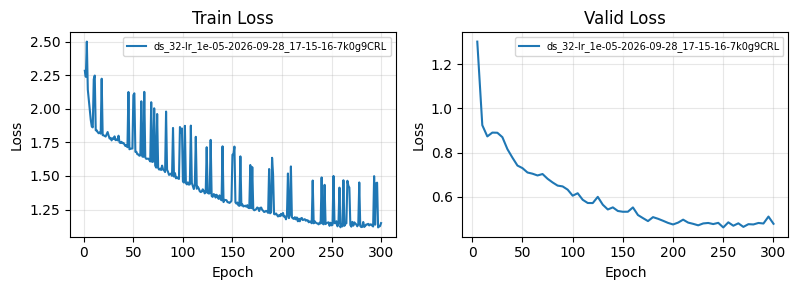

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

pkl_path = os.path.join(exp_dir, 'result.pkl')
with open(pkl_path, 'rb') as f:
    record = pickle.load(f)

label = os.path.basename(exp_dir)

train_epochs = sorted(record['train'].keys())
train_losses = [to_scalar(record['train'][e]['train_loss']) for e in train_epochs]
axes[0].plot(train_epochs, train_losses, label=label)

valid_epochs = sorted(record['valid'].keys())
valid_losses = [to_scalar(record['valid'][e]['valid_loss']) for e in valid_epochs]
axes[1].plot(valid_epochs, valid_losses, label=label)

axes[0].set_title('Train Loss')
axes[1].set_title('Valid Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
#-plt.savefig('loss_curves.png', dpi=150)
plt.show()

In [59]:
valid_losses = [(e, record['valid'][e]['valid_loss'].item()) for e in sorted(record['valid'].keys())]
for e, l in valid_losses:
    print(e, l)

5 1.3024847507476807
10 0.9242008924484253
15 0.8732417821884155
20 0.8905624151229858
25 0.8898835778236389
30 0.8699284195899963
35 0.8157857656478882
40 0.7772125005722046
45 0.7414025068283081
50 0.7297182083129883
55 0.709955632686615
60 0.7044603228569031
65 0.6964809894561768
70 0.7029901742935181
75 0.6814970970153809
80 0.6649011969566345
85 0.650544285774231
90 0.6469385623931885
95 0.6323032975196838
100 0.6048941612243652
105 0.6159920692443848
110 0.58637535572052
115 0.5718286633491516
120 0.5714658498764038
125 0.5995991826057434
130 0.5640225410461426
135 0.5424667000770569
140 0.5519826412200928
145 0.5356104373931885
150 0.5321670770645142
155 0.5323499441146851
160 0.5517669916152954
165 0.517352819442749
170 0.5033403038978577
175 0.4898792505264282
180 0.5078036785125732
185 0.5003933906555176
190 0.4913453757762909
195 0.48164448142051697
200 0.4746350347995758
205 0.48301661014556885
210 0.49638131260871887
215 0.4830590486526489
220 0.4774174690246582
225 0.4707

In [60]:
# rebuild args from the saved config
with open(f'{exp_dir}/config.json') as f:
    cfg = json.load(f)

In [61]:
valid_losses = [(e, record['valid'][e]['valid_loss'].item()) for e in sorted(record['valid'].keys())]
best_epoch, best_loss = min(valid_losses, key=lambda x: x[1])
print(best_epoch, best_loss)

250 0.46117743849754333


In [62]:
args = argparse.Namespace(**cfg)

# build model and load best validation weights
solver = MyFrame(CoRE_Net, dice_bce_loss, args, evalmode=True)
solver.load(f'{exp_dir}/weights/valid.th')
solver.eval()

In [63]:
def predict_mask(solver, img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img.astype(np.float32) / 255.0 * 3.2 - 1.6   # same normalization as test_one_img_from_path
    img_t = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).cuda()  # (1, C, H, W)

    with torch.no_grad():
        result = solver.net.forward(img_t)          # dict, since net is in eval mode
        pred = result['mask_logits'].sigmoid()        # apply sigmoid — logits aren't probabilities

    mask = pred.squeeze().cpu().numpy()
    mask_bin = (mask > 0.5).astype(np.uint8)
    return img, mask, mask_bin

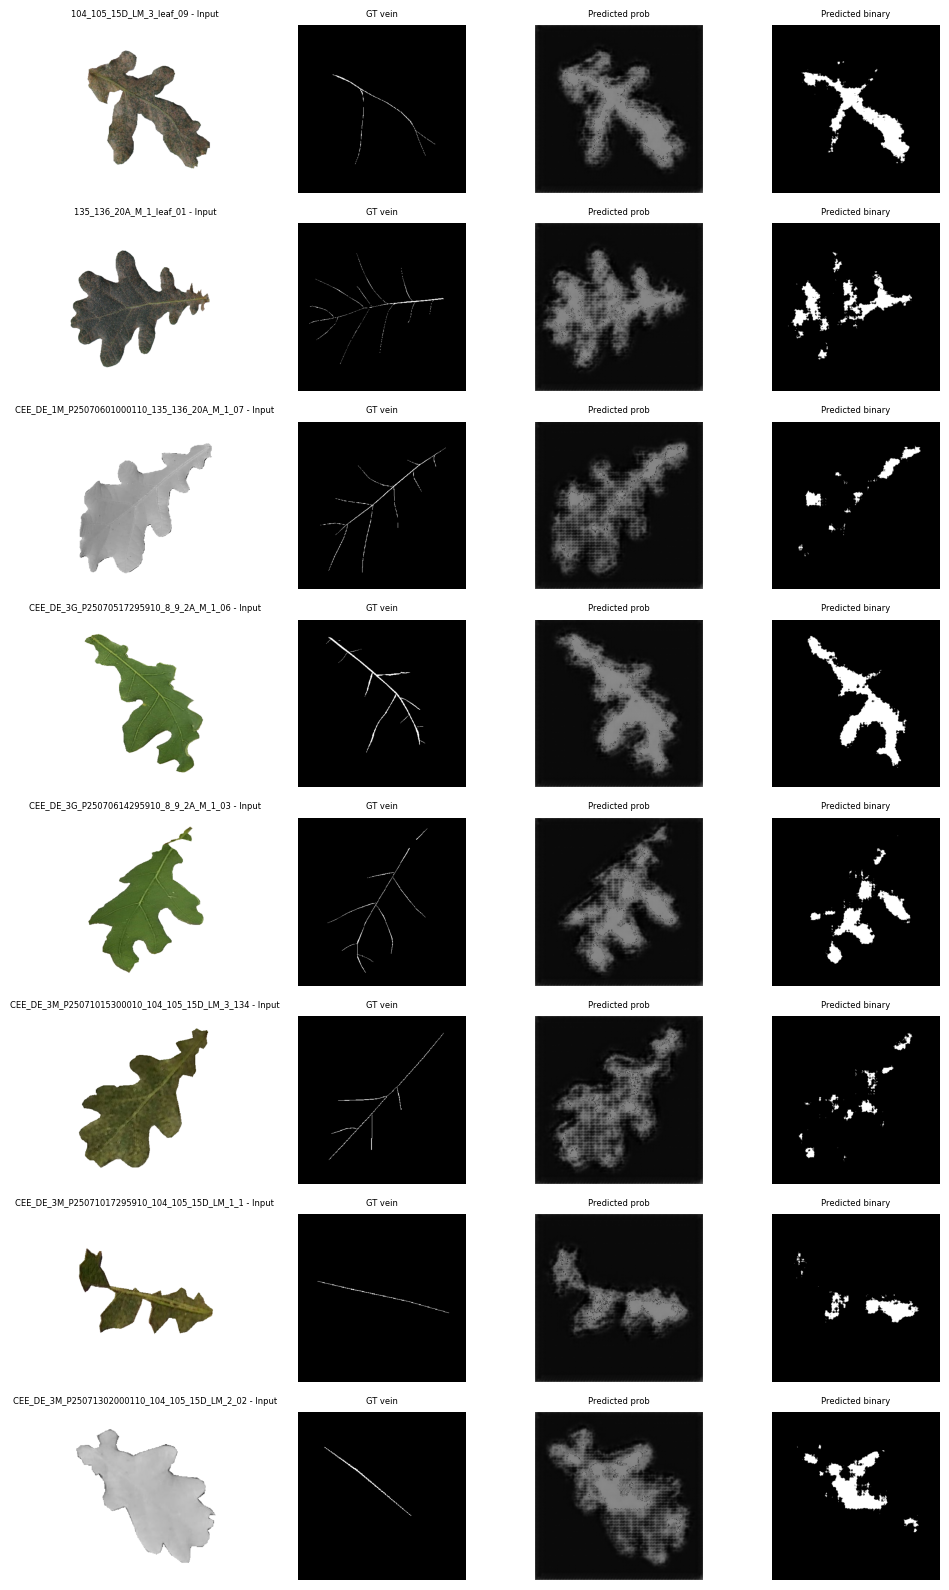

In [64]:
leaf_dirs = sorted(glob.glob(os.path.join(args.data_root, args.dataset, 'test/', '*')))

fig, axes = plt.subplots(len(leaf_dirs), 4, figsize=(10, 2 * len(leaf_dirs)))

for i, leaf_dir in enumerate(leaf_dirs):
    leaf_id = os.path.basename(leaf_dir)
    leaf_path = os.path.join(leaf_dir, 'leaf.png')
    vein_path = os.path.join(leaf_dir, 'vein.png')
    outline_path = os.path.join(leaf_dir, 'outline.png')

    orig, prob_mask, bin_mask = predict_mask(solver, leaf_path)
    gt_vein = cv2.imread(vein_path, cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(orig); axes[i, 0].set_title(f'{leaf_id} - Input', fontsize=6); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt_vein, cmap='gray'); axes[i, 1].set_title('GT vein', fontsize=6); axes[i, 1].axis('off')
    axes[i, 2].imshow(prob_mask, cmap='gray', vmin=0, vmax=1); axes[i, 2].set_title('Predicted prob', fontsize=6); axes[i, 2].axis('off')
    axes[i, 3].imshow(bin_mask, cmap='gray'); axes[i, 3].set_title('Predicted binary', fontsize=6); axes[i, 3].axis('off')

plt.tight_layout()
#-plt.savefig('inference_results.png', dpi=150)
plt.show()

In [12]:
print('prob mask min/max/mean:', prob_mask.min(), prob_mask.max(), prob_mask.mean())
print('prob mask std:', prob_mask.std())

prob mask min/max/mean: 7.696866e-06 0.9021615 0.05055765
prob mask std: 0.1137613


In [13]:
with open(f'{exp_dir}/result.pkl', 'rb') as f:
    record = pickle.load(f)

last_epoch = max(record['train'].keys())
print('epochs run:', last_epoch)
print('train_loss:', record['train'][last_epoch]['train_loss'])
print('valid_loss:', record['valid'][max(record['valid'].keys())]['valid_loss'])

epochs run: 300
train_loss: tensor(3.9261, device='cuda:0')
valid_loss: tensor(4.0938, device='cuda:0')


### get IoU

In [14]:
import json
import argparse
import torch
from networks.corenet import CoRE_Net
from networks.framework import MyFrame
from utils.loss import dice_bce_loss
from utils.data_iden import ImageFolder as ImageFolder_iden
from utils.metrics import calculate_IoU_Dice
import glog as log

In [15]:
with open(f'{exp_dir}/config.json') as f:
    cfg = json.load(f)
args = argparse.Namespace(**cfg)

solver = MyFrame(CoRE_Net, dice_bce_loss, args, evalmode=True)
solver.load(f'{exp_dir}/weights/valid.th')
solver.eval()

validset = ImageFolder_iden(root_path=args.data_root, datasets=args.dataset, mode='valid', is_random=False)
valid_loader = torch.utils.data.DataLoader(validset, batch_size=args.batch_size, shuffle=False, num_workers=4)

results, gt_seg_maps = [], []
with torch.no_grad():
    for img, mask, b_map in valid_loader:
        img = img.cuda()
        solver.set_input(img, mask, b_map)
        _, pred, _ = solver.test()
        for i in range(len(pred)):
            results.append(pred[i].squeeze().cpu().numpy())
            gt_seg_maps.append(mask[i].squeeze().cpu().numpy())

IoU_results, Dice_results = calculate_IoU_Dice(results, gt_seg_maps, logger=log, is_printTable=True)
print(IoU_results)
print(Dice_results)

I0928 15:50:14.261258 299462 data_iden.py:244] CEE_DE_3M_P25071017295910_104_105_15D_LM_3_09, 0.0
I0928 15:50:14.376651 299462 data_iden.py:244] CEE_DE_3G_P25070616295910_8_9_2A_M_1_07, 1.0
I0928 15:50:14.384400 299462 data_iden.py:244] CEE_DE_3M_P25071016000110_104_105_15D_LM_1_5, 2.0
I0928 15:50:14.389223 299462 data_iden.py:244] 104_105_15D_LM_1_leaf_5, 3.0
I0928 15:50:14.394547 299462 data_iden.py:244] CEE_DE_1M_P25070601000110_135_136_20A_M_1_11, 4.0
I0928 15:50:14.401399 299462 data_iden.py:244] CEE_DE_3M_P25071018300110_104_105_15D_LM_1_5, 5.0
I0928 15:50:14.923700 299462 metrics.py:293] per class results:
I0928 15:50:14.925327 299462 metrics.py:298] 
+------------+-------+-------+
| Class      | IoU   | Acc   |
+------------+-------+-------+
| background | 88.07 | 88.18 |
| vein       | 4.42  | 80.8  |
+------------+-------+-------+
I0928 15:50:14.925625 299462 metrics.py:299] Summary:
I0928 15:50:14.925943 299462 metrics.py:302] 
+--------+-------+-------+-------+
| Scope  | m

{'mIoU': np.float64(0.46240000000000003), 'mAcc': np.float64(0.8449), 'aAcc': np.float64(0.8813)}
{'mDice': np.float64(0.5106), 'mAcc': np.float64(0.8449), 'aAcc': np.float64(0.8813)}


In [16]:
for img, mask, b_map in valid_loader:
    print('mask mean (fraction labeled 1/vein):', mask.mean().item())
    print('mask unique values:', torch.unique(mask))
    break

mask mean (fraction labeled 1/vein): 0.005830725654959679
mask unique values: tensor([0., 1.])


In [17]:
import cv2
import numpy as np

# grab one validation image_name/path the same way ImageFolder_iden does
sample_outline = validset.outlines[0]
sample_vein = validset.veins[0]

outline = cv2.imread(sample_outline, cv2.IMREAD_GRAYSCALE)
vein = cv2.imread(sample_vein, cv2.IMREAD_GRAYSCALE)

print('outline unique:', np.unique(outline))
print('vein unique:', np.unique(vein))
print('vein mean (fraction white):', (vein > 127).mean())

outline unique: [  0 255]
vein unique: [  0 255]
vein mean (fraction white): 0.004553970025510204


In [18]:
outline = cv2.imread(sample_outline, cv2.IMREAD_GRAYSCALE)

print('outline unique:', np.unique(outline))
print('outline mean (fraction bright/255):', (outline > 127).mean())

outline unique: [  0 255]
outline mean (fraction bright/255): 0.27028360172193877


In [19]:
mask = vein.copy()
index = np.where(outline < 100)   # meant to select background (outside leaf)
mask[index] = outline[index]
print('mask mean after outline merge:', (mask > 127).mean())

_, mask_final = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('mask mean after Otsu:', (mask_final > 127).mean())

mask mean after outline merge: 0.004553970025510204
mask mean after Otsu: 0.004553970025510204


In [20]:
from utils.data_iden import image_reader, default_Dataset_loader

img, mask, b_map = image_reader(validset.images[0], validset.outlines[0], validset.veins[0])
print('mask mean right out of image_reader:', (mask > 127).mean())
print('mask shape/dtype:', mask.shape, mask.dtype)

img2, mask2, b_map2 = default_Dataset_loader(img, mask, b_map)
print('mask2 mean after default_Dataset_loader:', mask2.mean())
print('mask2 shape/dtype/unique:', mask2.shape, mask2.dtype, np.unique(mask2))

mask mean right out of image_reader: 0.004553970025510204
mask shape/dtype: (448, 448) uint8
mask2 mean after default_Dataset_loader: 0.00455397
mask2 shape/dtype/unique: (1, 448, 448) float32 [0. 1.]
